# Convolução: filtro de contorno (Sobel) e soma de variáveis aleatórias

Convolução do Kirby utilizando o filtro de contorno Sobel.

- **Topo:** imagem $\ast$ *kernel* de Sobel horizontal $=$ detecção de contornos.
  O kernel é
  $$K=\begin{bmatrix}-0{,}25&0&0{,}25\\-0{,}5&0&0{,}5\\-0{,}25&0&0{,}25\end{bmatrix},$$
  e a saída $g=K\ast I$ é colorida em **vermelho** (negativo) e **ciano** (positivo),
  com branco no zero.
- **Base:** convolução de duas distribuições discretas, $P_{X+Y}=P_X\ast P_Y$
  (a distribuição da soma de duas variáveis aleatórias independentes).

Saídas: `convolution-kirby.svg` (figura completa) e `favicon-kirby.svg`
(o Kirby filtrado, fundo transparente, para usar como favicon).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, to_rgb
from matplotlib.patches import Rectangle

# Paleta
PINK = "#ffafd2"   # corpo
CHEEK = "#ff79ac"  # bochechas
FEET = "#d83a4a"   # pés
EYE = "#221f5e"    # olhos
MOUTH = "#b8324f"  # boca
WHITE = "#ffffff"

NEG = np.array(to_rgb("#d61f2b"))  # vermelho (gradiente negativo)
POS = np.array(to_rgb("#11a8a8"))  # ciano   (gradiente positivo)

## 1. Sprite do Kirby (pixel-art procedural)

In [2]:
def _ellipse(xx, yy, cx, cy, rx, ry):
    return ((xx - cx) / rx) ** 2 + ((yy - cy) / ry) ** 2 <= 1.0


def make_kirby(n: int = 30, bg: str = "white") -> np.ndarray:
    """Retorna RGB float [n, n, 3] do Kirby sobre o fundo escolhido."""
    img = np.ones((n, n, 3)) * np.array(to_rgb(bg))
    cx = np.arange(n) + 0.5
    xx, yy = np.meshgrid(cx, cx)  # xx=coluna, yy=linha (y p/ baixo)

    def paint(mask, color):
        rgb = to_rgb(color)
        for k in range(3):
            img[..., k] = np.where(mask, rgb[k], img[..., k])

    paint(_ellipse(xx, yy, 15, 13.5, 10.0, 10.0), PINK)          # corpo
    paint(_ellipse(xx, yy, 5.5, 15.5, 3.2, 3.6), PINK)           # braço esq.
    paint(_ellipse(xx, yy, 24.5, 15.5, 3.2, 3.6), PINK)          # braço dir.
    paint(_ellipse(xx, yy, 9.8, 24.2, 5.2, 3.2), FEET)           # pé esq.
    paint(_ellipse(xx, yy, 21.2, 24.2, 5.2, 3.2), FEET)          # pé dir.
    paint(_ellipse(xx, yy, 9.5, 14.5, 2.3, 1.4), CHEEK)          # bochecha esq.
    paint(_ellipse(xx, yy, 21.0, 14.5, 2.3, 1.4), CHEEK)         # bochecha dir.
    paint(_ellipse(xx, yy, 15.0, 16.5, 1.4, 1.0), MOUTH)         # boca
    for ex in (12.2, 18.0):                                       # olhos + brilho
        paint(_ellipse(xx, yy, ex, 10.5, 1.7, 3.6), EYE)
        paint(_ellipse(xx, yy, ex, 8.7, 1.0, 1.3), WHITE)
    return img

## 2. Convolução 2D: filtro de Sobel horizontal

In [3]:
KERNEL = np.array([
    [-0.25, 0.0, 0.25],
    [-0.50, 0.0, 0.50],
    [-0.25, 0.0, 0.25],
])


def sobel_edges(rgb: np.ndarray) -> np.ndarray:
    """Aplica o kernel à luminância; retorna mapa assinado normalizado [-1, 1]."""
    from scipy.ndimage import convolve
    lum = rgb @ np.array([0.299, 0.587, 0.114])
    g = convolve(lum, KERNEL, mode="nearest")
    m = np.abs(g).max()
    return g / m if m else g


def edges_to_rgba(g: np.ndarray, white_bg: bool = True) -> np.ndarray:
    """Mapa assinado -> RGBA. Branco no zero (figura) ou transparente (favicon)."""
    n = g.shape[0]
    out = np.ones((n, n, 4))
    mag = np.abs(g)
    for k in range(3):
        col = np.where(g < 0, NEG[k], POS[k])
        out[..., k] = 1.0 - mag * (1.0 - col)  # branco -> cor conforme |g|
    out[..., 3] = 1.0 if white_bg else np.clip(mag * 2.6, 0, 1)
    return out

## 3. Helpers de desenho (grade de pixels vetorial p/ SVG nítido)

In [4]:
def draw_pixels(ax, rgba, grid=True):
    n = rgba.shape[0]
    if rgba.shape[2] == 3:
        rgba = np.dstack([rgba, np.ones((n, n))])
    for r in range(n):
        for c in range(n):
            ax.add_patch(Rectangle((c, n - 1 - r), 1, 1,
                                   facecolor=rgba[r, c], edgecolor="none"))
    if grid:
        for i in range(n + 1):
            ax.plot([i, i], [0, n], color="#cfcfcf", lw=0.35, zorder=5)
            ax.plot([0, n], [i, i], color="#cfcfcf", lw=0.35, zorder=5)
    ax.set_xlim(0, n)
    ax.set_ylim(0, n)
    ax.set_aspect("equal")
    ax.axis("off")


def draw_kernel(ax, K):
    for i in range(3):
        for j in range(3):
            v = K[i, j]
            mag = abs(v) / 0.5
            if v < 0:
                fc = 1.0 - mag * (1.0 - NEG)
            elif v > 0:
                fc = 1.0 - mag * (1.0 - POS)
            else:
                fc = np.array([0.97, 0.97, 0.97])
            ax.add_patch(Rectangle((j, 2 - i), 1, 1, facecolor=fc,
                                   edgecolor="white", lw=2.2))
            tc = "white" if mag > 0.4 else "#333333"
            ax.text(j + 0.5, 2 - i + 0.5, f"{v:.2f}", ha="center",
                    va="center", color=tc, fontsize=12, fontweight="bold")
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    ax.set_aspect("equal")
    ax.axis("off")


def grad_colors(c0, c1, n):
    cm = LinearSegmentedColormap.from_list("g", [c0, c1])
    return [cm(t) for t in np.linspace(0, 1, n)]


def draw_hist(ax, heights, colors):
    x = np.arange(len(heights))
    ax.bar(x, heights, width=0.9, color=colors, edgecolor="none")
    ax.set_ylim(0, max(heights) * 1.12)
    ax.set_xlim(-0.7, len(heights) - 0.3)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

## 4. Distribuições de probabilidade  $P_{X+Y}=P_X\ast P_Y$

In [5]:
P_X = np.array([1.0, 2.1, 3.3, 4.2, 3.3, 1.8, 1.2])
P_Y = np.array([4.3, 2.5, 1.6, 1.15, 0.85, 0.62, 0.5, 0.42, 0.36])
P_X = P_X / P_X.sum()
P_Y = P_Y / P_Y.sum()
P_XY = np.convolve(P_X, P_Y)  # distribuição da soma X + Y

## 5. Montagem da figura completa

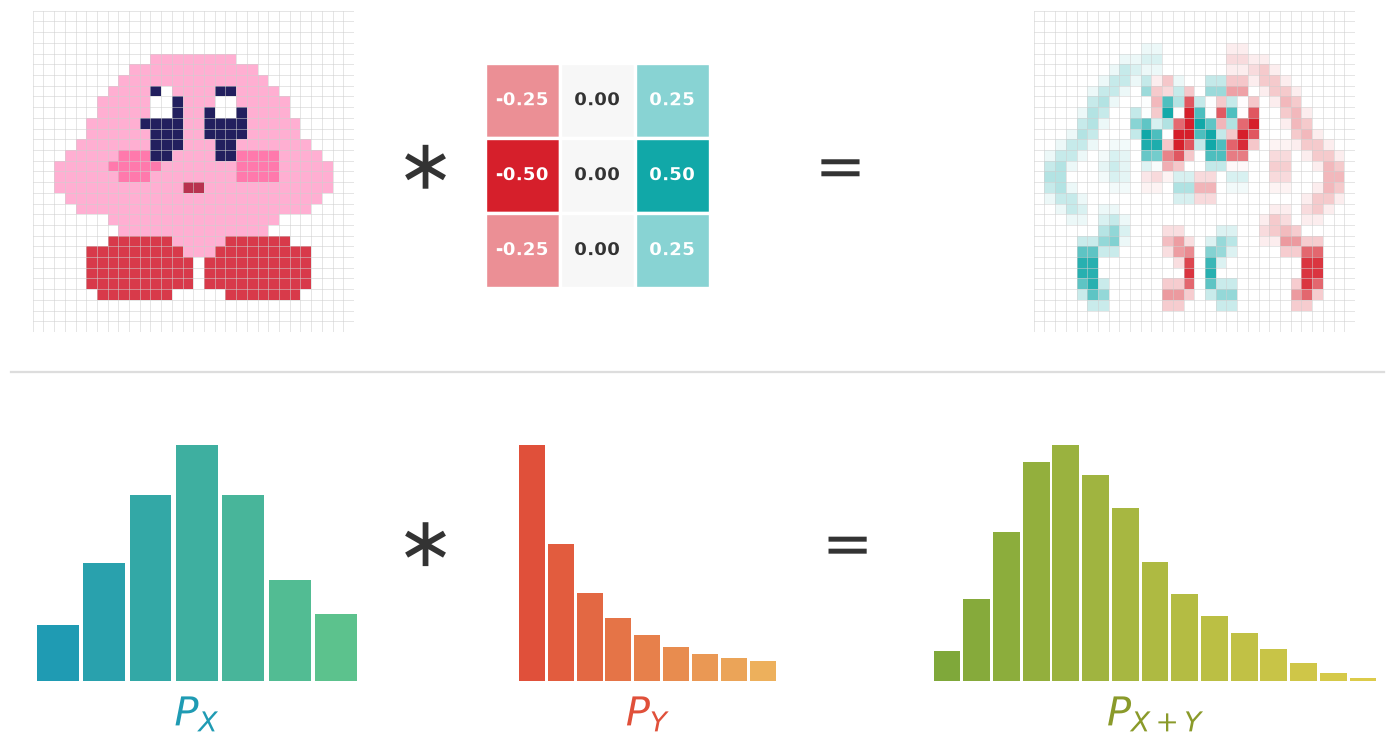

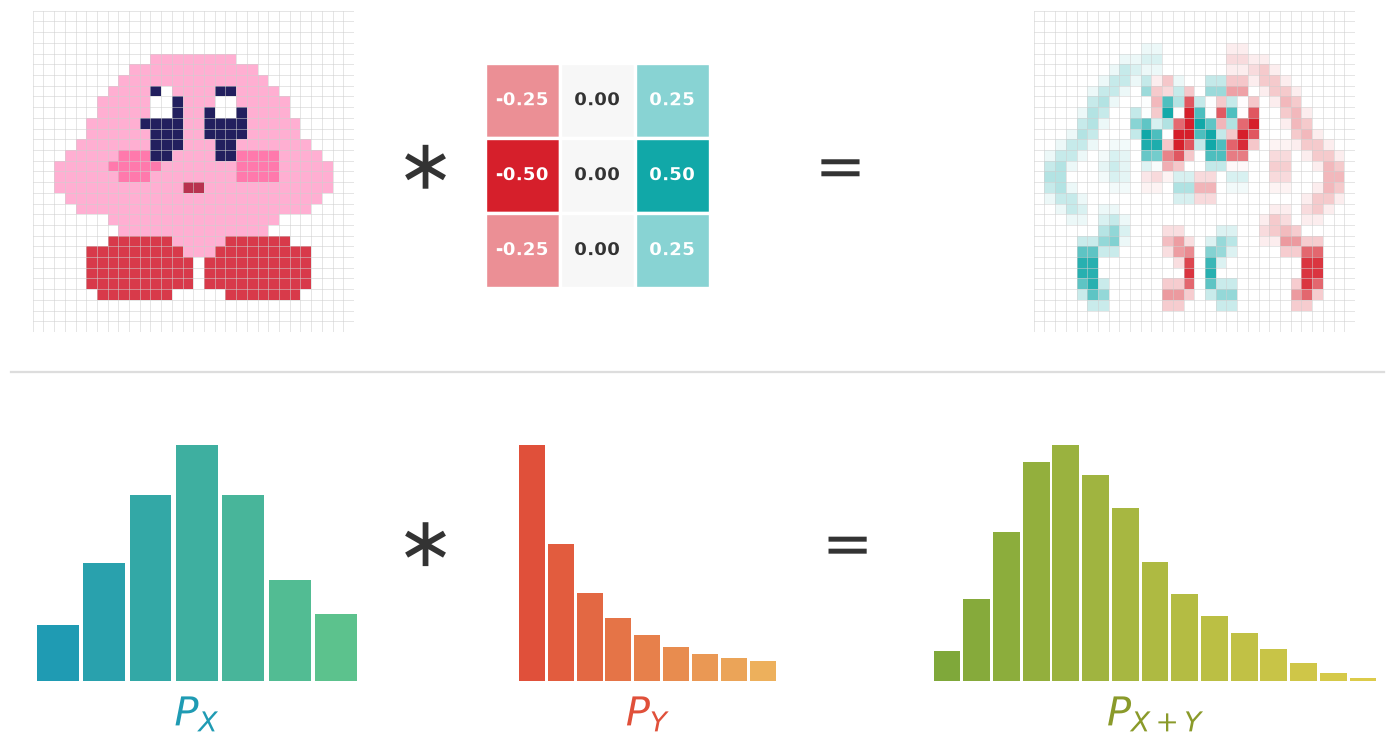

In [6]:
def build_figure():
    kirby = make_kirby(30)
    g = sobel_edges(kirby)
    edges = edges_to_rgba(g, white_bg=True)

    fig = plt.figure(figsize=(13, 7.3), dpi=110)
    fig.patch.set_facecolor("white")

    # topo
    draw_pixels(fig.add_axes([0.015, 0.545, 0.265, 0.40]), kirby)
    draw_kernel(fig.add_axes([0.350, 0.60, 0.16, 0.28]), KERNEL)
    draw_pixels(fig.add_axes([0.715, 0.545, 0.265, 0.40]), edges)
    fig.text(0.310, 0.745, r"$\ast$", ha="center", va="center", fontsize=46, color="#333")
    fig.text(0.600, 0.745, "=", ha="center", va="center", fontsize=40, color="#333")

    # divisória
    fig.add_artist(plt.Line2D([0.02, 0.98], [0.495, 0.495], color="#dddddd", lw=1.5))

    # base
    draw_hist(fig.add_axes([0.03, 0.11, 0.24, 0.33]), P_X,
              grad_colors("#1f9bb3", "#5cc28d", len(P_X)))
    draw_hist(fig.add_axes([0.37, 0.11, 0.19, 0.33]), P_Y,
              grad_colors("#e0503a", "#edb05c", len(P_Y)))
    draw_hist(fig.add_axes([0.66, 0.11, 0.32, 0.33]), P_XY,
              grad_colors("#7fa83a", "#dccb4a", len(P_XY)))
    fig.text(0.310, 0.275, r"$\ast$", ha="center", va="center", fontsize=46, color="#333")
    fig.text(0.605, 0.275, "=", ha="center", va="center", fontsize=40, color="#333")
    fig.text(0.15, 0.055, r"$P_X$", ha="center", fontsize=26, color="#1f9bb3")
    fig.text(0.465, 0.055, r"$P_Y$", ha="center", fontsize=26, color="#e0503a")
    fig.text(0.82, 0.055, r"$P_{X+Y}$", ha="center", fontsize=26, color="#8a9a2a")
    return fig, g


fig, g = build_figure()
fig.savefig("convolution-kirby.svg", facecolor="white", bbox_inches="tight")
fig.savefig("convolution-kirby.png", facecolor="white", bbox_inches="tight", dpi=160)
fig

## 6. Favicon: o Kirby filtrado (fundo transparente)

Calculado a partir do Kirby sobre fundo **preto**, para realçar a silhueta
(como no vídeo original). Exportado em SVG vetorial.

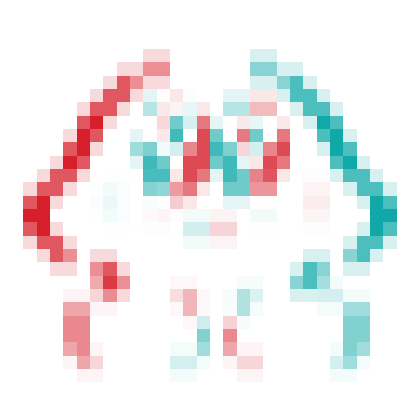

In [8]:
fav = edges_to_rgba(sobel_edges(make_kirby(30, "black")), white_bg=False)
ff = plt.figure(figsize=(4, 4), dpi=100)
draw_pixels(ff.add_axes([0, 0, 1, 1]), fav, grid=False)
ff.savefig("favicon-kirby.svg", transparent=True, bbox_inches="tight", pad_inches=0)